In [1]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS1_Functions.r')

In [2]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [3]:
save_plot_multiple <- function(plot, filename) {
  # Save as PNG
  ggsave(paste0(filename, ".png"), plot = plot, width = 30, height = 38, dpi = 300)
  
  # Save as SVG
  ggsave(paste0(filename, ".svg"), plot = plot, width = 30, height = 38)
  
  # Save as PDF
  ggsave(paste0(filename, ".pdf"), plot = plot, width = 30, height = 38)
}




In [4]:
save_plot_multiple2 <- function(plot, filename) {
  # Save as PNG
  ggsave(paste0(filename, ".png"), plot = plot, width = 10, height = 10, dpi = 300)
  
  # Save as SVG
  ggsave(paste0(filename, ".svg"), plot = plot, width = 10, height = 8)
  
  # Save as PDF
  ggsave(paste0(filename, ".pdf"), plot = plot, width = 10, height = 8)
}



In [5]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS2_Plot_Config.r')

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [6]:
library(nichenetr) # Please update to v2.0.4
library(Seurat)
library(SeuratObject)
library(tidyverse)

Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘sp’


The following object is masked from ‘package:ggraph’:

    geometry



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:backports’:

    %||%


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘Seurat’


The following object is masked from ‘package:backports’:

    %||%




In [7]:
setwd("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks")

In [8]:

lr_network = readRDS(url("https://zenodo.org/record/3260758/files/lr_network.rds")) # ligand receptor interactions

In [9]:
head(lr_network)

from,to,source,database
<chr>,<chr>,<chr>,<chr>
CXCL1,CXCR2,kegg_cytokines,kegg
CXCL2,CXCR2,kegg_cytokines,kegg
CXCL3,CXCR2,kegg_cytokines,kegg
CXCL5,CXCR2,kegg_cytokines,kegg
PPBP,CXCR2,kegg_cytokines,kegg
CXCL6,CXCR2,kegg_cytokines,kegg


In [10]:
weighted_networks = readRDS(url("https://zenodo.org/record/3260758/files/weighted_networks.rds")) # integrated weighted ligand-signaling and gene regulatory network
ligand_target_matrix = readRDS(url("https://zenodo.org/record/3260758/files/ligand_target_matrix.rds"))  # gene-gene regulatory scores
# gives the regulatory potential of a target gene based on the ligand-tf & tf- target-gene links and weights of the signaling and gr network (multiply PPR of each ligand -tf  pair with the weights of the gr network)
          

In [11]:
head(weighted_networks)

from,to,weight
<chr>,<chr>,<dbl>
A1BG,ABCC6,0.42164389
A1BG,ACE2,0.10074109
A1BG,ADAM10,0.09698978
A1BG,AGO1,0.05245879
A1BG,AKT1,0.08553468
A1BG,ANXA7,0.45659947
A1BG,APOA4,0.15220107
A1BG,BCL2L1,0.12622385
A1BG,CDKN1A,0.23363504


In [12]:
head(ligand_target_matrix)

,CXCL1,CXCL2,CXCL3,CXCL5,PPBP,CXCL6,CXCL8,CXCL9,CXCL10,CXCL11,⋯,PCDHGB1,CDH6,CDH9,CDH12,CDH18,PCDHB16,PCDHA7,PCDHA6,PCDHA4,PCDHA12
A1BG,3.534343e-04,4.041324e-04,3.729920e-04,3.080640e-04,2.628388e-04,2.728028e-04,0.0004135450,2.979898e-04,4.160383e-04,3.076497e-04,⋯,3.030235e-04,0.0003193876,3.233872e-04,3.482791e-04,3.928653e-04,0.0003343214,3.349091e-04,2.876452e-04,3.661495e-04,3.227585e-04
A1BG-AS1,1.650894e-04,1.509213e-04,1.583594e-04,1.317253e-04,1.231819e-04,1.177621e-04,0.0002167180,1.413245e-04,1.699601e-04,1.367743e-04,⋯,1.595498e-04,0.0001639842,1.644583e-04,1.775159e-04,2.105883e-04,0.0001445265,1.660374e-04,1.404391e-04,1.838989e-04,1.754163e-04
A1CF,5.787175e-04,4.596295e-04,3.895907e-04,3.293275e-04,3.211944e-04,3.092715e-04,0.0004828988,3.695226e-04,3.932868e-04,3.576349e-04,⋯,4.253005e-04,0.0016635451,1.589106e-03,9.403964e-04,1.422321e-03,0.0004323049,5.746119e-04,5.355883e-04,5.168501e-04,4.032690e-04
A2M,6.027058e-04,5.996617e-04,5.164365e-04,4.517236e-04,4.590521e-04,4.162023e-04,0.0007034187,5.406831e-04,6.157032e-04,4.973532e-04,⋯,4.727750e-04,0.0005078260,4.973407e-04,5.873858e-04,5.701905e-04,0.0005136738,5.357690e-04,4.966255e-04,5.716795e-04,5.542914e-04
A2M-AS1,8.898724e-05,8.243341e-05,7.484018e-05,4.912514e-05,5.120439e-05,4.794787e-05,0.0001375803,5.511592e-05,6.135325e-05,8.012598e-05,⋯,3.175308e-05,0.0000775283,7.658853e-05,7.908294e-05,7.983814e-05,0.0000331484,8.098718e-05,4.823759e-06,4.961643e-05,7.985996e-05
A2ML1,2.113030e-04,2.702934e-04,1.824742e-04,1.495898e-04,1.581763e-04,1.543523e-04,0.0002417026,1.784508e-04,2.727467e-04,1.798256e-04,⋯,2.164137e-04,0.0002077279,2.013055e-04,2.331335e-04,2.273070e-04,0.0001874981,4.884798e-04,1.952864e-04,3.509499e-04,2.201941e-04


In [10]:
# Set longer timeout first
#options(timeout = 300)

# Correct URLs (all under record 3260758)
#lr_network = readRDS(url("https://zenodo.org/record/3260758/files/lr_network.rds"))
#ligand_target_matrix = readRDS(url("https://zenodo.org/record/3260758/files/ligand_target_matrix.rds"))
#weighted_networks = readRDS(url("https://zenodo.org/record/3260758/files/weighted_networks.rds"))

In [13]:
library(readxl)
factor3ccc = read_excel("factor3_ccc.xlsx")

In [14]:
head(factor3ccc)

Factor3,type,variable_name,gene
<dbl>,<chr>,<chr>,<chr>
0.06532119,Activated.T.cells,Activated.T.cells__AAK1,AAK1
0.35685062,Activated.T.cells,Activated.T.cells__ABLIM1,ABLIM1
-0.47819405,Activated.T.cells,Activated.T.cells__AC007952.4,AC007952.4
-0.17591274,Activated.T.cells,Activated.T.cells__AC016831.7,AC016831.7
-0.46738408,Activated.T.cells,Activated.T.cells__AC022217.3,AC022217.3
-0.52896990,Activated.T.cells,Activated.T.cells__AC023424.3,AC023424.3


In [15]:
unique(factor3ccc$type)

[1] "Activated.T.cells"       "B.Cells"                
 [3] "Classical.Monocytes"     "clinical"               
 [5] "Dendritic.cells"         "NK.cells"               
 [7] "Non.Classical.Monocytes" "proteomic"              
 [9] "Regulatory.T.cells"      "T.cells"

In [24]:
percent_genes = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/01_Prepared_sc_Data_Gene_Expr_per_Cell_Type.csv")
head(percent_genes)

,X,perc_cells_expressing_gene,total_amount_cells_expressing_gene,gene,cluster,dataset
,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
1,0,0.015556938,4,AL627309.1,T.cells,Prepared_sc_Data
2,1,0.019446173,5,AL627309.5,T.cells,Prepared_sc_Data
3,2,0.303360299,78,LINC01409,T.cells,Prepared_sc_Data
4,3,0.917859365,236,LINC01128,T.cells,Prepared_sc_Data
5,4,0.073895457,19,LINC00115,T.cells,Prepared_sc_Data
6,5,0.003889235,1,SAMD11,T.cells,Prepared_sc_Data


In [ ]:
# RUN THIS FIRST TO CREATE THE FILES NEEDED BEFORE RUNNING THIS ENTIRE CODE!!!! THIS IS THE CODE TO CREATE BACKGROUND GENES FILES FOR EACH CELL TYPE BASED ON PERCENTAGE OF GENES EXPRESSED IN CELLS
# Filter genes with `perc_cells_expressing_gene > 0.10`
#filtered_data <- percent_genes %>% filter(perc_cells_expressing_gene > 0.10)

# Group by cluster and save each gene list as a separate CSV file
#unique_clusters <- unique(filtered_data$cluster)

#for (cluster in unique_clusters) {
  # Filter data for the current cluster
#  cluster_data <- filtered_data %>% filter(cluster == !!cluster)
#  print(cluster)
#  print(nrow(cluster_data %>% select(gene)))
  # Save the gene list to a CSV file
#  output_file <- paste0(cluster, "_gene_list.csv") %>%
#  gsub(" ", "_", .) # Replace spaces with underscores in file names
#  write_csv(cluster_data %>% select(gene), output_file)
#}


In [16]:
receiver <- "Activated.T.cells"


In [18]:
#dir.create(receiver)

In [17]:
setwd(paste0("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/",receiver))

In [19]:
#dir.create("positive")

In [20]:
setwd(paste0("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/",receiver,"/positive"))

In [21]:
temp = "pos"

In [22]:


if (temp == "pos") {
  top_genes_receiver <- factor3ccc %>%
    filter(type == receiver, Factor3 > 0.2) %>%
    pull(gene)
} else {
  top_genes_receiver <- factor3ccc %>%
    filter(type == receiver, Factor3 < -0.2) %>%
    pull(gene)
}

In [23]:
length(top_genes_receiver)

[1] 195

In [ ]:
write.csv(top_genes_receiver, paste0("top_genes_receiver_positive",receiver,".csv"))

In [25]:
receiver_genes = read.csv(paste0("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/",receiver,"_gene_list.csv"))
expressed_genes_receiver <- receiver_genes$gene
expressed_genes_receiver

[1] "LINC01409"      "LINC01128"      "NOC2L"          "HES4"          
    [5] "ISG15"          "C1orf159"       "AL390719.3"     "TNFRSF18"      
    [9] "TNFRSF4"        "SDF4"           "B3GALT6"        "UBE2J2"        
   [13] "ACAP3"          "PUSL1"          "INTS11"         "CPTP"          
   [17] "DVL1"           "AURKAIP1"       "CCNL2"          "MRPL20-AS1"    
   [21] "MRPL20"         "ATAD3C"         "ATAD3B"         "ATAD3A"        
   [25] "SSU72"          "AL645728.1"     "AL691432.2"     "MIB2"          
   [29] "CDK11B"         "SLC35E2B"       "CDK11A"         "SLC35E2A"      
   [33] "NADK"           "GNB1"           "PRKCZ"          "FAAP20"        
   [37] "SKI"            "AL590822.3"     "MORN1"          "RER1"          
   [41] "PEX10"          "PLCH2"          "AL139246.5"     "TNFRSF14-AS1"  
   [45] "TNFRSF14"       "AL139246.3"     "PRXL2B"         "MEGF6"         
   [49] "TPRG1L"         "WRAP73"         "SMIM1"          "LRRC47"        
   [53] "CEP104"         "DFFB"           "C1orf174"       "AL365255.1"    
   [57] "NPHP4"          "KCNAB2"         "RPL22"          "ICMT"          
   [61] "ACOT7"          "AL031848.2"     "TNFRSF25"       "PLEKHG5"       
   [65] "NOL9"           "TAS1R1"         "ZBTB48"         "KLHL21"        
   [69] "PHF13"          "THAP3"          "DNAJC11"        "CAMTA1-DT"     
   [73] "CAMTA1"         "VAMP3"          "PER3"           "PARK7"         
   [77] "AL034417.3"     "ERRFI1"         "RERE"           "ENO1"          
   [81] "ENO1-AS1"       "CA6"            "H6PD"           "SPSB1"         
   [85] "LINC02606"      "SLC25A33"       "PIK3CD"         "PIK3CD-AS2"    
   [89] "CLSTN1"         "CTNNBIP1"       "LZIC"           "NMNAT1"        
   [93] "RBP7"           "UBE4B"          "KIF1B"          "PGD"           
   [97] "CENPS"          "DFFA"           "PEX14"          "CASZ1"         
  [101] "TARDBP"         "AL109811.2"     "SRM"            "EXOSC10"       
  [105] "AL109811.1"     "MTOR"           "UBIAD1"         "DISP3"         
  [109] "FBXO2"          "FBXO44"         "FBXO6"          "MAD2L2"        
  [113] "AGTRAP"         "MTHFR"          "CLCN6"          "AL021155.5"    
  [117] "KIAA2013"       "MFN2"           "MIIP"           "TNFRSF1B"      
  [121] "VPS13D"         "DHRS3"          "PRDM2"          "KAZN"          
  [125] "AL031283.1"     "EFHD2"          "CASP9"          "DNAJC16"       
  [129] "AGMAT"          "AL121992.1"     "DDI2"           "PLEKHM2"       
  [133] "FBLIM1"         "AL450998.2"     "SPEN"           "ZBTB17"        
  [137] "FBXO42"         "SZRD1"          "SPATA21"        "NECAP2"        
  [141] "AL137802.2"     "NBPF1"          "CROCC"          "BX284668.5"    
  [145] "BX284668.6"     "AL049569.1"     "ATP13A2"        "SDHB"          
  [149] "PADI4"          "RCC2"           "ALDH4A1"        "IFFO2"         
  [153] "UBR4"           "EMC1-AS1"       "EMC1"           "MRTO4"         
  [157] "AKR7A2"         "SLC66A1"        "CAPZB"          "MICOS10"       
  [161] "AL031727.2"     "NBL1"           "TMCO4"          "OTUD3"         
  [165] "UBXN10-AS1"     "CAMK2N1"        "MUL1"           "CDA"           
  [169] "PINK1"          "PINK1-AS"       "DDOST"          "HP1BP3"        
  [173] "EIF4G3"         "ECE1"           "AL031728.1"     "NBPF3"         
  [177] "USP48"          "LINC01635"      "LINC00339"      "CDC42"         
  [181] "CDC42-AS1"      "ZBTB40"         "KDM1A"          "AL031428.1"    
  [185] "LUZP1"          "HNRNPR"         "ZNF436"         "TCEA3"         
  [189] "ID3"            "MDS2"           "RPL11"          "ELOA-AS1"      
  [193] "ELOA"           "PITHD1"         "LYPLA2"         "GALE"          
  [197] "HMGCL"          "FUCA1"          "PNRC2"          "SRSF10"        
  [201] "STPG1"          "NIPAL3"         "RCAN3AS"        "RCAN3"         
  [205] "NCMAP-DT"       "SRRM1"          "CLIC4"          "RUNX3"         
  [209] "AL031432.1"     "SYF2"           "RSRP1"   

In [26]:
length(expressed_genes_receiver)

[1] 13473

In [27]:
all_receptors <- unique(lr_network$to)
expressed_receptors <- intersect(all_receptors, expressed_genes_receiver)

In [28]:
potential_ligands <- lr_network[lr_network$to %in% expressed_receptors, ]
potential_ligands <- unique(potential_ligands$from)

length(potential_ligands)

[1] 589

In [ ]:
write.csv(potential_ligands, paste0("potential_ligands_for_",receiver,"positive.csv"))

In [29]:
unique(percent_genes$cluster)

[1] "T.cells"                        "Regulatory.T.cells"            
 [3] "Classical.Monocytes"            "B.cells"                       
 [5] "NK.cells"                       "Platelets"                     
 [7] "Activated.T.cells"              "Dendritic.cells"               
 [9] "Plasma cells"                   "Non.Classical.Monocytes"       
[11] "Metabolically active Monocytes" "Erythrocytes"

In [30]:
unique(factor3ccc$type)

[1] "Activated.T.cells"       "B.Cells"                
 [3] "Classical.Monocytes"     "clinical"               
 [5] "Dendritic.cells"         "NK.cells"               
 [7] "Non.Classical.Monocytes" "proteomic"              
 [9] "Regulatory.T.cells"      "T.cells"

In [ ]:

# Define sender cell types
#sender_celltypes <- c('T.cells','Regulatory.T.cells','Classical.Monocytes','B.cells','NK.cells','Classical.Monocytes','Non.Classical.Monocytes')

# Filter MOFA data for sender cell types
#mofa_sender_data <- percent_genes %>% filter(cluster %in% sender_celltypes)

# Define the function to get expressed genes for a specific cell type
#get_expressed_genes <- function(celltype, data, pct = 0.15) {
#  data %>%
#  filter(cluster == celltype, perc_cells_expressing_gene > pct) %>%
#  pull(gene)
#}

# Get the list of expressed genes for all sender cell types
#list_expressed_genes_sender <- lapply(sender_celltypes, get_expressed_genes, data = mofa_sender_data, pct = 0.15)
# Combine expressed genes across all sender cell types
#expressed_genes_sender <- unique(unlist(list_expressed_genes_sender))


In [ ]:
#length(expressed_genes_sender)

In [ ]:

# Filter for potential ligands (e.g., pre-defined list of ligands from NicheNet)
#potential_ligands_focused <- intersect(potential_ligands, expressed_genes_sender)

# Output the focused ligands
#focused_ligands <- mofa_sender_data %>%
#  filter(gene %in% potential_ligands_focused)

# Save results to a CSV file
#write.csv(focused_ligands, "Filtered_MOFA_Ligands.csv", row.names = FALSE)

# View the first few rows
#print(head(focused_ligands))

#potential_ligands = focused_ligands$gene

In [ ]:
# Assuming potential_ligands is a vector of ligands
#length(potential_ligands_focused)


In [31]:
background_expressed_genes <- expressed_genes_receiver %>% .[. %in% rownames(ligand_target_matrix)]

In [32]:
ligand_activities <- predict_ligand_activities(
geneset = top_genes_receiver,
background_expressed_genes = background_expressed_genes,
ligand_target_matrix = ligand_target_matrix,
potential_ligands = potential_ligands)
ligand_activities <- ligand_activities %>% arrange(-aupr_corrected) %>% mutate(rank = rank(desc(aupr_corrected)))
head(ligand_activities)

test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL17F,0.6681392,0.04403248,0.02766330,0.08659187,1
ASIP,0.6804212,0.04397547,0.02760629,0.09456250,2
LAMB1,0.6513648,0.04297071,0.02660154,0.07642207,3
IL17A,0.6801926,0.04273273,0.02636355,0.09288314,4
TNC,0.6532717,0.04189594,0.02552677,0.08098281,5
MMP9,0.6557326,0.04180618,0.02543701,0.08011536,6


In [ ]:
write.csv(ligand_activities, paste0("ligand_activities_positive",receiver,"_.csv"))

In [33]:
nrow(ligand_activities)

[1] 589

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


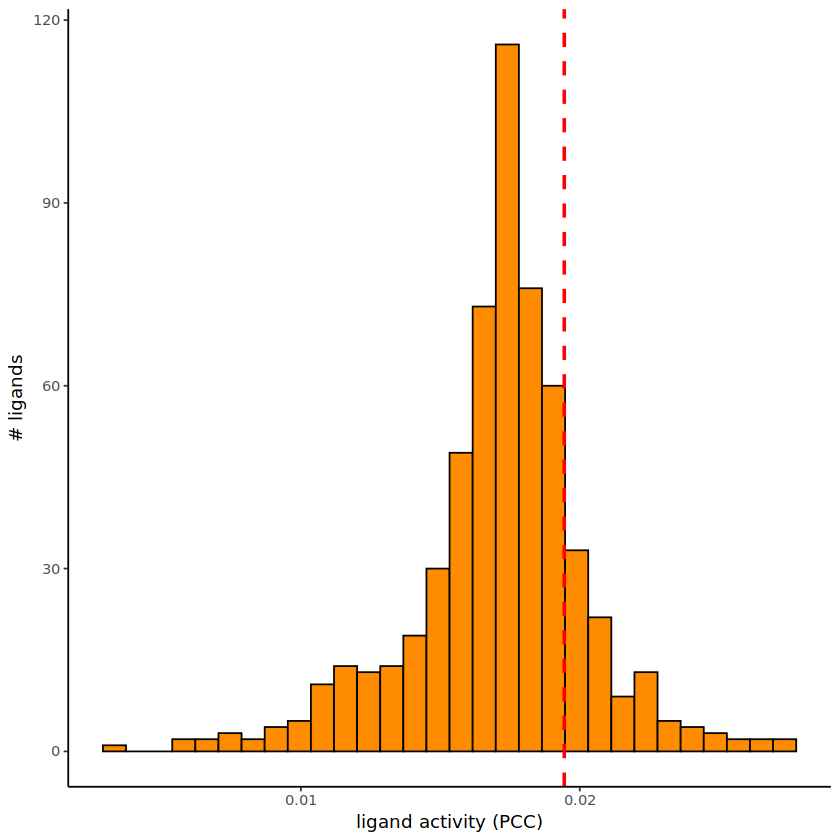

In [34]:
p_hist_lig_activity <- ggplot(ligand_activities, aes(x=aupr_corrected)) + 
  geom_histogram(color="black", fill="darkorange")  + 
  geom_vline(aes(xintercept=min(ligand_activities %>% top_n(100, aupr_corrected) %>% pull(aupr_corrected))),
             color="red", linetype="dashed", size=1) + 
  labs(x="ligand activity (PCC)", y = "# ligands") +
  theme_classic()

p_hist_lig_activity

In [ ]:
save_plot_multiple(p_hist_lig_activity, paste0("positive_ligand_activity_histogram_top_100"))

In [ ]:
#ligand_activities_all <- ligand_activities
#ligand_activities <- ligand_activities[
#ligand_activities$test_ligand %in% potential_ligands, ]


In [35]:
best_upstream_ligands <- ligand_activities %>% top_n(100, aupr_corrected) %>% arrange(-aupr_corrected) %>% pull(test_ligand)

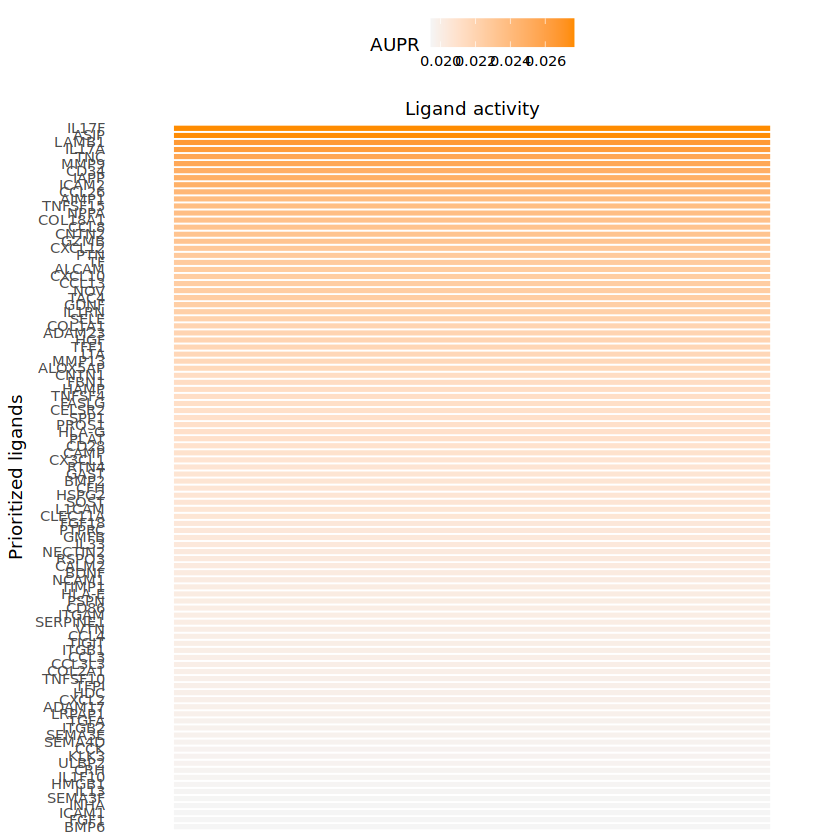

In [36]:
vis_ligand_aupr <- ligand_activities %>% filter(test_ligand %in% best_upstream_ligands) %>%
  column_to_rownames("test_ligand") %>% select(aupr_corrected) %>% arrange(aupr_corrected) %>% as.matrix(ncol = 1)

heatmap_aupr = (make_heatmap_ggplot(vis_ligand_aupr,
                     "Prioritized ligands", "Ligand activity", 
                     legend_title = "AUPR", color = "darkorange") + 
    theme(axis.text.x.top = element_blank()))  
heatmap_aupr

In [ ]:
save_plot_multiple(heatmap_aupr, paste0("positive_heatmap_aupr_top_100"))

In [37]:
geneset_oi = top_genes_receiver

In [38]:
active_ligand_target_links_df <- best_upstream_ligands %>%
  lapply(get_weighted_ligand_target_links,
         geneset = geneset_oi,
         ligand_target_matrix = ligand_target_matrix,
         n = 100) %>%
  bind_rows() %>% drop_na()

nrow(active_ligand_target_links_df)

[1] 721

In [39]:
head(active_ligand_target_links_df)

ligand,target,weight
<chr>,<chr>,<dbl>
IL17F,AKAP13,0.002705245
IL17F,JUNB,0.003177270
IL17F,KLF6,0.002896597
IL17F,LMNA,0.002936423
IL17F,MCL1,0.002762700
IL17F,MIDN,0.002868774


In [40]:
active_ligand_target_links <- prepare_ligand_target_visualization(
  ligand_target_df = active_ligand_target_links_df,
  ligand_target_matrix = ligand_target_matrix,
  cutoff = 0.2) 
nrow(active_ligand_target_links)

[1] 43

In [41]:
head(active_ligand_target_links)

,RTN4,AIMP1,TAC4,IL13,BMP6,CXCL12,PTN,CAMP,IAPP,FASLG,⋯,ITGAM,LRPAP1,CCL26,COL18A1,ITGB2,IL1F10,CNTN1,FGF18,ASIP,CCL8
PPIB,0.000000000,0,0,0,0,0,0.000000000,0.003368348,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SPOCK2,0.000000000,0,0,0,0,0,0.000000000,0.003610589,0,0,⋯,0,0,0,0,0,0,0,0,0,0
IDS,0.000000000,0,0,0,0,0,0.000000000,0.003349348,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERP29,0.000000000,0,0,0,0,0,0.004141351,0.000000000,0,0,⋯,0,0,0,0,0,0,0,0,0,0
PDIA3,0.000000000,0,0,0,0,0,0.004156748,0.002961256,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ARPC2,0.001757748,0,0,0,0,0,0.000000000,0.000000000,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [42]:

order_ligands <- intersect(best_upstream_ligands, colnames(active_ligand_target_links)) %>% rev()
order_targets <- active_ligand_target_links_df$target %>% unique() %>% intersect(rownames(active_ligand_target_links))

vis_ligand_target <- t(active_ligand_target_links[order_targets,order_ligands])

heatmap_regulatory_potential = make_heatmap_ggplot(vis_ligand_target, "Prioritized ligands", "Predicted target genes",
                    color = "purple", legend_title = "Regulatory potential") +
  scale_fill_gradient2(low = "whitesmoke",  high = "purple")

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [ ]:
save_plot_multiple(heatmap_regulatory_potential, paste0("positive_heatmap_regulatory_potential_top_300"))

In [43]:
ligand_receptor_links_df <- get_weighted_ligand_receptor_links(
  best_upstream_ligands, expressed_receptors,
  lr_network, weighted_networks$lr_sig) 

In [44]:
vis_ligand_receptor_network <- prepare_ligand_receptor_visualization(
  ligand_receptor_links_df,
  best_upstream_ligands,
  order_hclust = "both") 

heatmap_prior_interaction_potential = (make_heatmap_ggplot(t(vis_ligand_receptor_network), 
                     y_name = "Ligands", x_name = "Receptors",  
                     color = "mediumvioletred", legend_title = "Prior interaction potential"))

In [ ]:
save_plot_multiple(heatmap_prior_interaction_potential, paste0("positive_heatmap_prior_interaction_potential_top_300"))

In [45]:
head(percent_genes)

,X,perc_cells_expressing_gene,total_amount_cells_expressing_gene,gene,cluster,dataset
,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
1,0,0.015556938,4,AL627309.1,T.cells,Prepared_sc_Data
2,1,0.019446173,5,AL627309.5,T.cells,Prepared_sc_Data
3,2,0.303360299,78,LINC01409,T.cells,Prepared_sc_Data
4,3,0.917859365,236,LINC01128,T.cells,Prepared_sc_Data
5,4,0.073895457,19,LINC00115,T.cells,Prepared_sc_Data
6,5,0.003889235,1,SAMD11,T.cells,Prepared_sc_Data


In [46]:
head(best_upstream_ligands)

[1] "IL17F" "ASIP"  "LAMB1" "IL17A" "TNC"   "MMP9"

In [47]:
top_ligands = best_upstream_ligands
clusters_to_remove <- c(receiver,'Platelets', 'Plasma cells','Metabolically active Monocytes', 'Erythrocytes')# Add cluster names to remove
percent_genes_filtered <- percent_genes %>%
  filter(!cluster %in% clusters_to_remove)
#Assign each ligand to the cell type where it's most highly expressed
assign_ligands_to_celltypes <- function(percent_genes, top_ligands) {
  
  # Filter for your top ligands only
  ligand_expression <- percent_genes %>%
    filter(gene %in% top_ligands)
  
  # For each ligand, find the cell type with highest expression percentage
  ligand_assignments <- ligand_expression %>%
    group_by(gene) %>%
    slice_max(perc_cells_expressing_gene, n = 1, with_ties = FALSE) %>%
    select(ligand_type = cluster, ligand = gene) %>%
    ungroup()
  
  return(ligand_assignments)
}

result_df <- assign_ligands_to_celltypes(percent_genes_filtered, top_ligands)


In [48]:
result_df

ligand_type,ligand
<chr>,<chr>
Classical.Monocytes,ADAM17
Dendritic.cells,ADAM23
T.cells,AIMP1
Classical.Monocytes,ALCAM
NK.cells,ALOX5AP
B.cells,ASIP
T.cells,BDNF
NK.cells,BMP2
Classical.Monocytes,BMP6


In [49]:
ligand_type_indication_df = result_df

In [50]:
active_ligand_target_links_df <- best_upstream_ligands %>%
  lapply(get_weighted_ligand_target_links,
         geneset = top_genes_receiver,
         ligand_target_matrix = ligand_target_matrix,
         n = 100) %>% bind_rows()

active_ligand_target_links_df <- active_ligand_target_links_df %>%
  mutate(target_type = receiver)

In [51]:
head(active_ligand_target_links_df)

ligand,target,weight,target_type
<chr>,<chr>,<dbl>,<chr>
IL17F,AKAP13,0.002705245,Activated.T.cells
IL17F,JUNB,0.003177270,Activated.T.cells
IL17F,KLF6,0.002896597,Activated.T.cells
IL17F,LMNA,0.002936423,Activated.T.cells
IL17F,MCL1,0.002762700,Activated.T.cells
IL17F,MIDN,0.002868774,Activated.T.cells


In [52]:
# Clean the data first to remove NA values
active_ligand_target_links_df_clean <- active_ligand_target_links_df %>%
  filter(!is.na(weight)) %>%
  filter(is.finite(weight))

# Then run the function
circos_links <- get_ligand_target_links_oi(ligand_type_indication_df, 
                                          active_ligand_target_links_df_clean,
                                          cutoff = 0.1) 

Joining with `by = join_by(ligand)`


In [53]:
unique(circos_links$ligand_type)

[1] "B.cells"                 "Dendritic.cells"        
[3] "Classical.Monocytes"     "Non.Classical.Monocytes"
[5] "T.cells"                 "NK.cells"               
[7] "Regulatory.T.cells"

In [54]:
head(circos_links)

ligand,target,weight,target_type,ligand_type
<chr>,<chr>,<dbl>,<chr>,<chr>
ASIP,B2M,0.001274952,Activated.T.cells,B.cells
ASIP,CD44,0.001342055,Activated.T.cells,B.cells
ASIP,JUNB,0.001372303,Activated.T.cells,B.cells
ASIP,LMNA,0.001230453,Activated.T.cells,B.cells
ASIP,PFN1,0.001163661,Activated.T.cells,B.cells
ASIP,PTMA,0.001434323,Activated.T.cells,B.cells


In [ ]:
write.csv(circos_links, paste0("circos_interactions_positive.csv"))

In [55]:
unique(circos_links$ligand_type)

[1] "B.cells"                 "Dendritic.cells"        
[3] "Classical.Monocytes"     "Non.Classical.Monocytes"
[5] "T.cells"                 "NK.cells"               
[7] "Regulatory.T.cells"

In [58]:
ligand_colors_colorblind <- c(
  "B.cells" = "#AA4499",        # Orange
  "Regulatory.T.cells" = "#CC79A7",                # Pink
  "Classical.Monocytes" = "#56B4E9",              # Sky Blue
  "T.cells" = "#009E73",            # Bluish Green
  "Non.Classical.Monocytes" = "#882255",             # Blue
  "NK.cells" = "#D55E00",                       # Vermillion
  "Dendritic.cells" = "#F0E442"                        # Yellow
)
target_colors <- c("Activated.T.cells" = "tomato")




vis_circos_obj <- prepare_circos_visualization(circos_links,
                                               ligand_colors = ligand_colors_colorblind,
                                               target_colors = target_colors,
                                               celltype_order = NULL) 

Joining with `by = join_by(ligand_type)`
Joining with `by = join_by(target_type)`


In [59]:
vis_circos_obj

ligand,target,weight
<chr>,<chr>,<dbl>
ASIP,B2M,0.001274952
ASIP,CD44,0.001342055
ASIP,JUNB,0.001372303
ASIP,LMNA,0.001230453
ASIP,PFN1,0.001163661
ASIP,PTMA,0.001434323
ASIP,SUB1,0.001119604
ASIP,TAGLN2,0.001163845
ASIP,ZFP36,0.001234402


In [60]:
ligand_colors = ligand_colors_colorblind

NULL

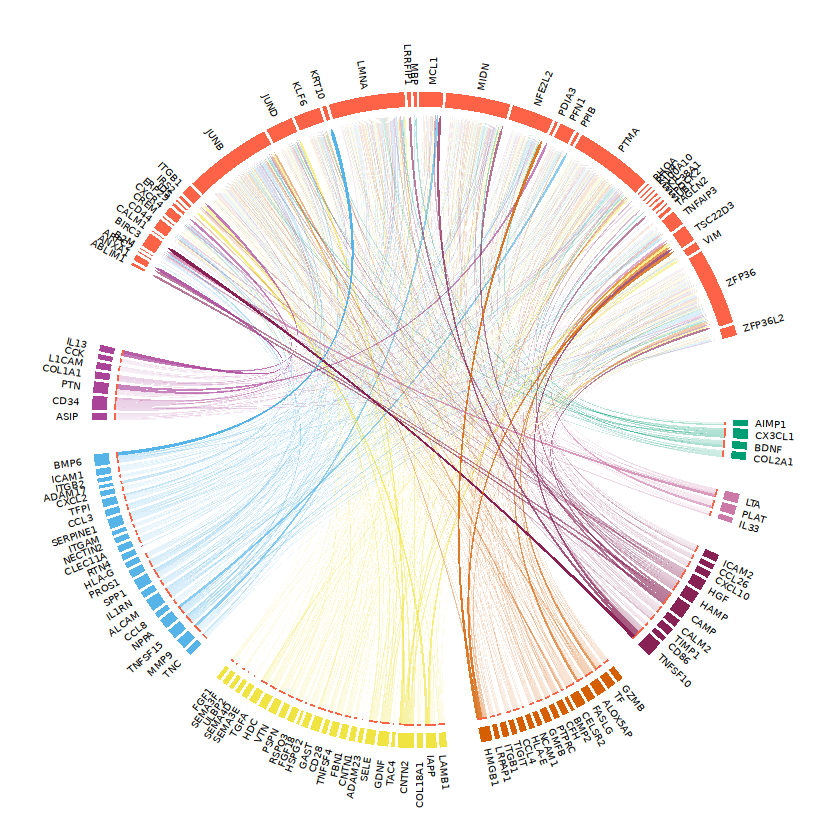

In [61]:
mofa_factor3_ligands_interaction_with_transparency = make_circos_plot(vis_circos_obj, transparency = TRUE,  args.circos.text = list(cex = 0.5)) 
mofa_factor3_ligands_interaction_with_transparency

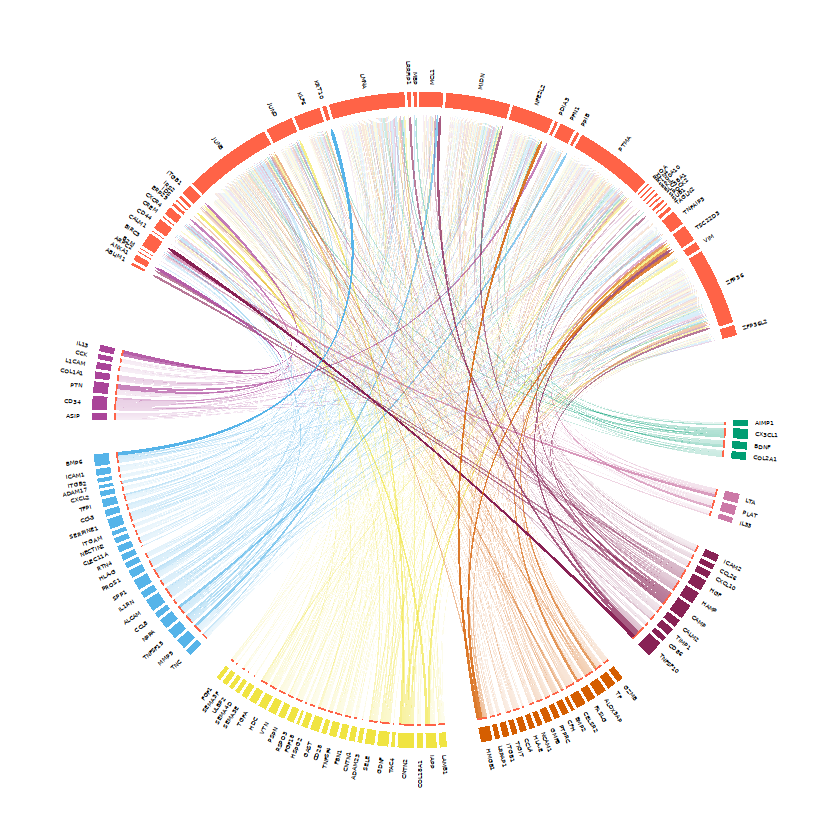

In [62]:
mofa_factor3_ligands_interaction_with_transparency <- make_circos_plot(
  vis_circos_obj, 
  transparency = TRUE, 
  args.circos.text = list(
    cex = 0.3,
    facing = "clockwise",
    niceFacing = TRUE,
    adj = c(0, 0.5)
  )
)

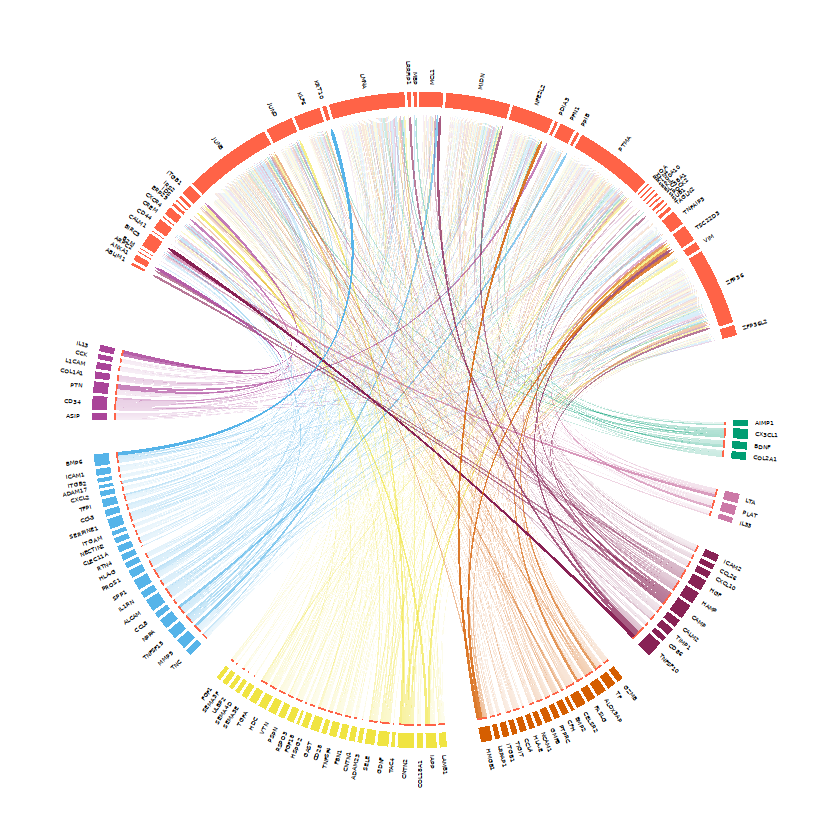

In [63]:
actual_ligand_types <- unique(circos_links$ligand_type)
actual_target_types <- unique(circos_links$target_type)

# Filter ligand colors to only include those actually present
ligand_colors_filtered <- ligand_colors_colorblind[names(ligand_colors_colorblind) %in% actual_ligand_types]

# Create legend with only the colors that appear in your plot
legend_colors <- c(ligand_colors_filtered, target_colors)
legend_labels <- c(names(ligand_colors_filtered), names(target_colors))

# Now create your legend
circos_legend <- ComplexHeatmap::Legend(
  labels = legend_labels,
  background = legend_colors,
  type = "point",
  grid_height = unit(3, "mm"),
  grid_width = unit(3, "mm"),
  labels_gp = grid::gpar(fontsize = 8)
)
# Capture the legend as a grob
circos_legend_grob <- grid::grid.grabExpr(ComplexHeatmap::draw(circos_legend))





mofa_factor3_ligands_interaction_with_transparency <- make_circos_plot(
  vis_circos_obj, 
  transparency = TRUE, 
  args.circos.text = list(
    cex = 0.3,
    facing = "clockwise",
    niceFacing = TRUE,
    adj = c(0, 0.5)
  )
)

# Record the plot
p_circos_with_legend <- recordPlot()

In [64]:
mofa_factor3_ligands_interaction_with_legend = cowplot::plot_grid(p_circos_with_legend, circos_legend_grob, rel_widths = c(10, 6))

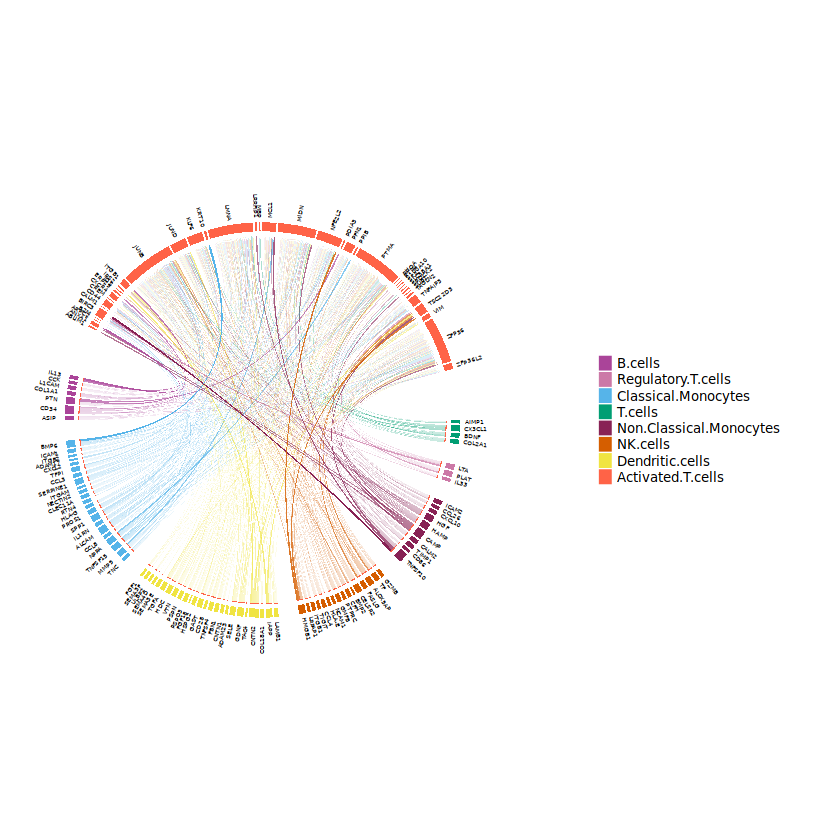

In [65]:
mofa_factor3_ligands_interaction_with_legend

In [ ]:
save_plot_multiple2(mofa_factor3_ligands_interaction_with_legend, paste0("mofa_factor3_ligands_interaction_with_legend_positive"))

In [ ]:
# Replace ligand-receptor interaction potentials with correlations of genes from our single-cell data

In [11]:
circos_links = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/Classical.Monocytes/positive/circos_interactions_positive.csv")

In [66]:
head(circos_links)

ligand,target,weight,target_type,ligand_type
<chr>,<chr>,<dbl>,<chr>,<chr>
ASIP,B2M,0.001274952,Activated.T.cells,B.cells
ASIP,CD44,0.001342055,Activated.T.cells,B.cells
ASIP,JUNB,0.001372303,Activated.T.cells,B.cells
ASIP,LMNA,0.001230453,Activated.T.cells,B.cells
ASIP,PFN1,0.001163661,Activated.T.cells,B.cells
ASIP,PTMA,0.001434323,Activated.T.cells,B.cells


In [97]:
df = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/02_results/final/02_Combined_Data_CGS_v3_INTEGRATED_final.csv")
head(df)

,X,sample_id,variable,value,type,gene
,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,HF10,Activated.T.cells__AAK1,0.4022501,Activated.T.cells,AAK1
2,2,HF11,Activated.T.cells__AAK1,0.0000000,Activated.T.cells,AAK1
3,3,HF12,Activated.T.cells__AAK1,-0.1573107,Activated.T.cells,AAK1
4,4,HF13,Activated.T.cells__AAK1,0.5485223,Activated.T.cells,AAK1
5,5,HF14,Activated.T.cells__AAK1,-0.6420614,Activated.T.cells,AAK1
6,6,HF15,Activated.T.cells__AAK1,0.7245144,Activated.T.cells,AAK1


In [98]:
# Function to replace NicheNet weights with sample-level correlations
replace_weights_with_correlations <- function(circos_links, expression_data) {
  
  # Create a function to calculate correlation for each ligand-target pair
  calculate_correlation <- function(ligand, target, ligand_type, target_type) {
    
    # Filter expression data for ligand from ligand_type samples
    ligand_expr <- expression_data %>%
      filter(gene == ligand & type == ligand_type) %>%
      select(sample_id, value)
    
    # Filter expression data for target from target_type samples  
    target_expr <- expression_data %>%
      filter(gene == target & type == target_type) %>%
      select(sample_id, value)
    
    # Merge by sample_id to get paired values
    merged_data <- inner_join(ligand_expr, target_expr, 
                             by = "sample_id", 
                             suffix = c("_ligand", "_target"))
    
    # Calculate correlation if we have enough data points
    if(nrow(merged_data) >= 3 && 
       length(unique(merged_data$value_ligand)) > 1 && 
       length(unique(merged_data$value_target)) > 1) {
      
      cor_result <- cor.test(merged_data$value_ligand, 
                            merged_data$value_target, 
                            method = "pearson")
      
      return(list(
        correlation = cor_result$estimate,
        p_value = cor_result$p.value,
        n_samples = nrow(merged_data)
      ))
      
    } else {
      return(list(
        correlation = 0,
        p_value = 1,
        n_samples = nrow(merged_data)
      ))
    }
  }
  
  # Apply correlation calculation to each row
  correlation_results <- circos_links %>%
    rowwise() %>%
    mutate(
      cor_data = list(calculate_correlation(ligand, target, ligand_type, target_type)),
      new_weight = cor_data$correlation,
      p_value = cor_data$p_value,
      n_samples = cor_data$n_samples
    ) %>%
    ungroup() %>%
    select(-cor_data)  # Remove the list column
  
  # Replace the weight column with correlations
  circos_links_updated <- correlation_results %>%
    mutate(
      original_weight = weight,      # Save original NicheNet weight FIRST
      weight = abs(new_weight)       # Then replace with absolute correlation
    ) %>%
    select(ligand, target, weight, target_type, ligand_type, 
           correlation = new_weight, p_value, n_samples, original_weight)
  
  return(circos_links_updated)
}


In [99]:
circos_links_with_correlations <- replace_weights_with_correlations(circos_links, df)

In [100]:
head(circos_links_with_correlations)

ligand,target,weight,target_type,ligand_type,correlation,p_value,n_samples,original_weight
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
ASIP,B2M,0,Activated.T.cells,B.cells,0,1,0,0.001274952
ASIP,CD44,0,Activated.T.cells,B.cells,0,1,0,0.001342055
ASIP,JUNB,0,Activated.T.cells,B.cells,0,1,0,0.001372303
ASIP,LMNA,0,Activated.T.cells,B.cells,0,1,0,0.001230453
ASIP,PFN1,0,Activated.T.cells,B.cells,0,1,0,0.001163661
ASIP,PTMA,0,Activated.T.cells,B.cells,0,1,0,0.001434323


In [ ]:
write.csv(circos_links_with_correlations, "circos_links_with_correlations_positive.csv")

In [25]:
circos_links_with_correlations = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/Activated.T.cells/positive/circos_links_with_correlations_positive.csv")

In [101]:
strong_correlation_links <- circos_links_with_correlations %>%
  filter(abs(correlation) > 0.4 & p_value < 0.05)
strong_correlation_links

ligand,target,weight,target_type,ligand_type,correlation,p_value,n_samples,original_weight
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
CALM2,ZFP36,0.4031362,Activated.T.cells,Non.Classical.Monocytes,-0.4031362,8.965703e-05,99,0.001360563
ITGB1,JUNB,0.6040707,Activated.T.cells,NK.cells,-0.6040707,9.118617e-11,99,0.001228556
ITGB1,JUND,0.4842740,Activated.T.cells,NK.cells,-0.4842740,6.614410e-07,99,0.000974817
ITGB1,ZFP36,0.4266566,Activated.T.cells,NK.cells,-0.4266566,1.621874e-05,99,0.001141423
CCL3,TNFAIP3,0.4659125,Activated.T.cells,Classical.Monocytes,0.4659125,2.864769e-06,99,0.001599279
CXCL2,TNFAIP3,0.4748262,Activated.T.cells,Classical.Monocytes,0.4748262,1.734208e-06,99,0.001076835
CXCL2,ZFP36,0.4523981,Activated.T.cells,Classical.Monocytes,0.4523981,5.971966e-06,99,0.001092873
ADAM17,CXCR4,0.4560616,Activated.T.cells,Classical.Monocytes,0.4560616,4.908779e-06,99,0.002409098


In [ ]:
write.csv(strong_correlation_links, "circos_strong_correlation_links_positive.csv")

In [115]:
strong_correlation_links = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/Activated.T.cells/positive/circos_strong_correlation_links_positive.csv")
head(strong_correlation_links)

,X,ligand,target,weight,target_type,ligand_type,correlation,p_value,n_samples,original_weight
,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
1,1,CALM2,ZFP36,0.4031362,Activated.T.cells,Non.Classical.Monocytes,-0.4031362,8.965703e-05,99,0.001360563
2,2,ITGB1,JUNB,0.6040707,Activated.T.cells,NK.cells,-0.6040707,9.118617e-11,99,0.001228556
3,3,ITGB1,JUND,0.4842740,Activated.T.cells,NK.cells,-0.4842740,6.614410e-07,99,0.000974817
4,4,ITGB1,ZFP36,0.4266566,Activated.T.cells,NK.cells,-0.4266566,1.621874e-05,99,0.001141423
5,5,CCL3,TNFAIP3,0.4659125,Activated.T.cells,Classical.Monocytes,0.4659125,2.864769e-06,99,0.001599279
6,6,CXCL2,TNFAIP3,0.4748262,Activated.T.cells,Classical.Monocytes,0.4748262,1.734208e-06,99,0.001076835


In [ ]:
# Create scatter plots for each strong correlation pair
library(ggplot2)
library(dplyr)

# Function to create scatter plot for a ligand-target pair
create_correlation_scatter <- function(ligand, target, ligand_type, target_type, correlation_value, df) {
  
  # Get ligand expression data
  ligand_data <- df %>%
    filter(gene == ligand & type == ligand_type) %>%
    select(sample_id, ligand_value = value)
  
  # Get target expression data  
  target_data <- df %>%
    filter(gene == target & type == target_type) %>%
    select(sample_id, target_value = value)
  
  # Merge the data
  plot_data <- inner_join(ligand_data, target_data, by = "sample_id")
  
  # Create the plot (target on X-axis, ligand on Y-axis) - no correlation line
  p <- ggplot(plot_data, aes(x = target_value, y = ligand_value)) +
    geom_point(size = 2, alpha = 0.7, color = "black") +
    labs(
      x = paste0(target, " (", target_type, ")"),
      y = paste0(ligand, " (", ligand_type, ")"),
      title = paste0(target, " vs ", ligand),
      subtitle = paste0("Cor = ", round(correlation_value, 2))
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5, size = 12),
      axis.title = element_text(size = 11),
      axis.text = element_text(size = 10)
    ) +
    scale_x_continuous(expand = expansion(mult = 0.05)) +  # Prevent point removal
    scale_y_continuous(expand = expansion(mult = 0.05))
  
  return(p)
}

# Create plots for all strong correlations
create_all_correlation_plots <- function(strong_correlation_links, df, output_dir = ".") {
  
  # Create output directory if it doesn't exist
  if (!dir.exists(output_dir)) {
    dir.create(output_dir, recursive = TRUE)
  }
  
  # Loop through each strong correlation pair
  for (i in 1:nrow(strong_correlation_links)) {
    
    row <- strong_correlation_links[i, ]
    
    # Create the plot
    p <- create_correlation_scatter(
      ligand = row$ligand,
      target = row$target,
      ligand_type = row$ligand_type,
      target_type = row$target_type,
      correlation_value = row$correlation,
      df = df
    )
    
    # Create filename
    filename <- paste0(
      output_dir, "/",
      "scatter_", row$ligand, "_vs_", row$target, "_",
      gsub("[^A-Za-z0-9]", "_", row$ligand_type), ".pdf"
    )
    
    # Save as PDF
    ggsave(filename, plot = p, width = 6, height = 5, device = "pdf")
    
    cat("Saved:", filename, "\n")
  }
  
  cat("All scatter plots saved!\n")
}

# Run the function to create all plots
create_all_correlation_plots(strong_correlation_links, df, output_dir = "correlation_scatter_plots")

# Preview: Create just the first plot to check
if (nrow(strong_correlation_links) > 0) {
  preview_plot <- create_correlation_scatter(
    ligand = strong_correlation_links$ligand[1],
    target = strong_correlation_links$target[1],
    ligand_type = strong_correlation_links$ligand_type[1], 
    target_type = strong_correlation_links$target_type[1],
    correlation_value = strong_correlation_links$correlation[1],
    df = df
  )
  
  print(preview_plot)
}

In [38]:
# Function to extract and save correlation input data
save_correlation_inputs <- function(circos_links, expression_data, output_dir = "correlation_inputs") {
  
  # Create output directory
  if(!dir.exists(output_dir)) {
    dir.create(output_dir, recursive = TRUE)
  }
  
  # Create a function to extract and save input data for each ligand-target pair
  extract_and_save_inputs <- function(ligand, target, ligand_type, target_type, pair_id) {
    
    # Filter expression data for ligand from ligand_type samples
    ligand_expr <- expression_data %>%
      filter(gene == ligand & type == ligand_type) %>%
      select(sample_id, value)
    
    # Filter expression data for target from target_type samples  
    target_expr <- expression_data %>%
      filter(gene == target & type == target_type) %>%
      select(sample_id, value)
    
    # Merge by sample_id to get paired values
    merged_data <- inner_join(ligand_expr, target_expr, 
                             by = "sample_id", 
                             suffix = c("_ligand", "_target"))
    
    # Create a clean filename
    filename <- paste0(output_dir, "/", 
                      gsub("[^A-Za-z0-9_]", "_", ligand), "_", 
                      gsub("[^A-Za-z0-9_]", "_", target), "_",
                      ligand_type, "_", target_type, "_",
                      "pair", pair_id, ".csv")
    
    # Add metadata columns
    merged_data_save <- merged_data %>%
      mutate(
        ligand = ligand,
        target = target,
        ligand_type = ligand_type,
        target_type = target_type
      ) %>%
      select(ligand, target, ligand_type, target_type, 
             sample_id, ligand_value = value_ligand, target_value = value_target)
    
    # Save the file
    write.csv(merged_data_save, filename, row.names = FALSE)
    
    # Return summary info
    return(list(
      n_samples = nrow(merged_data),
      filename = filename
    ))
  }
  
  # Extract and save inputs for each row
  results <- circos_links %>%
    mutate(pair_id = row_number()) %>%
    rowwise() %>%
    mutate(
      extraction_data = list(extract_and_save_inputs(ligand, target, ligand_type, target_type, pair_id)),
      n_samples = extraction_data$n_samples,
      saved_file = extraction_data$filename
    ) %>%
    ungroup() %>%
    select(-extraction_data)
  
  # Create summary file
  summary_file <- results %>%
    select(ligand, target, ligand_type, target_type, n_samples, saved_file)
  
  write.csv(summary_file, paste0(output_dir, "/input_files_summary.csv"), row.names = FALSE)
  
  # Print summary
  cat("Saved", nrow(results), "input data files to:", output_dir, "\n")
  cat("Summary file saved as:", paste0(output_dir, "/input_files_summary.csv"), "\n")
  
  return(summary_file)
}

In [39]:
# Save all input files
summary <- save_correlation_inputs(strong_correlation_links, df)

# Specify custom output directory
summary <- save_correlation_inputs(strong_correlation_links, df, 
                                   output_dir = "my_input_data")

# View the summary
print(summary)

Saved 3 input data files to: correlation_inputs 
Summary file saved as: correlation_inputs/input_files_summary.csv 
Saved 3 input data files to: my_input_data 
Summary file saved as: my_input_data/input_files_summary.csv 
# A tibble: 3 × 6
  ligand target ligand_type         target_type       n_samples saved_file      
  <chr>  <chr>  <chr>               <chr>                 <int> <chr>           
1 CXCL2  IER2   Classical.Monocytes Activated.T.cells        99 my_input_data/C…
2 CXCL3  IER2   Classical.Monocytes Activated.T.cells        99 my_input_data/C…
3 CCL20  IER2   Classical.Monocytes Activated.T.cells        99 my_input_data/C…


In [68]:
head(circos_links)

ligand,target,weight,target_type,ligand_type
<chr>,<chr>,<dbl>,<chr>,<chr>
ASIP,B2M,0.001274952,Activated.T.cells,B.cells
ASIP,CD44,0.001342055,Activated.T.cells,B.cells
ASIP,JUNB,0.001372303,Activated.T.cells,B.cells
ASIP,LMNA,0.001230453,Activated.T.cells,B.cells
ASIP,PFN1,0.001163661,Activated.T.cells,B.cells
ASIP,PTMA,0.001434323,Activated.T.cells,B.cells


In [102]:
circos_links_with_correlations_new <- circos_links_with_correlations %>%
  select(-c("correlation", "p_value", "n_samples", "original_weight"))
head(circos_links_with_correlations_new)

ligand,target,weight,target_type,ligand_type
<chr>,<chr>,<dbl>,<chr>,<chr>
ASIP,B2M,0,Activated.T.cells,B.cells
ASIP,CD44,0,Activated.T.cells,B.cells
ASIP,JUNB,0,Activated.T.cells,B.cells
ASIP,LMNA,0,Activated.T.cells,B.cells
ASIP,PFN1,0,Activated.T.cells,B.cells
ASIP,PTMA,0,Activated.T.cells,B.cells


In [75]:
circos_links_with_correlations_new = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/Activated.T.cells/positive/circos_links_with_correlations_positive.csv")

In [103]:
circos_links_filtered <- circos_links_with_correlations_new %>%
  filter(weight > 0)

In [104]:
circos_links_filtered

ligand,target,weight,target_type,ligand_type
<chr>,<chr>,<dbl>,<chr>,<chr>
GZMB,JUNB,0.200724332,Activated.T.cells,NK.cells
GZMB,KLF6,0.295381346,Activated.T.cells,NK.cells
GZMB,LMNA,0.040108778,Activated.T.cells,NK.cells
GZMB,MIDN,0.062448682,Activated.T.cells,NK.cells
GZMB,NFE2L2,0.081897488,Activated.T.cells,NK.cells
GZMB,PTMA,0.009546189,Activated.T.cells,NK.cells
GZMB,ZFP36,0.051199041,Activated.T.cells,NK.cells
ALCAM,BIRC3,0.022972653,Activated.T.cells,Classical.Monocytes
ALCAM,JUNB,0.131167493,Activated.T.cells,Classical.Monocytes


In [105]:
unique(circos_links_filtered$ligand_type)

[1] "NK.cells"                "Classical.Monocytes"    
[3] "Non.Classical.Monocytes" "Dendritic.cells"

In [106]:
ligand_colors_colorblind <- c(
  #"B.cells" = "#FF6347",        # Orange
  #"Regulatory.T.cells" = "#8B7355",                # Pink
  "Classical.Monocytes" = "#4682B4", 
    #"Activated.T.cells" = "#FF7F50",# Sky Blue
  #"T.cells" = "#696969",            # Bluish Green
  "Non.Classical.Monocytes" = "#FF1493",             # Blue
  "NK.cells" = "#9370DB",
  "Dendritic.cells" = "#228B22"  # Yellow
)
target_colors <- c("Activated.T.cells" = "#FF7F50")







vis_circos_obj <- prepare_circos_visualization(circos_links_filtered,
                                               ligand_colors = ligand_colors_colorblind,
                                               target_colors = target_colors,
                                               celltype_order = NULL) 

Joining with `by = join_by(ligand_type)`
Joining with `by = join_by(target_type)`


In [107]:
vis_circos_obj

ligand,target,weight
<chr>,<chr>,<dbl>
GZMB,JUNB,0.200724332
GZMB,KLF6,0.295381346
GZMB,LMNA,0.040108778
GZMB,MIDN,0.062448682
GZMB,NFE2L2,0.081897488
GZMB,PTMA,0.009546189
GZMB,ZFP36,0.051199041
ALCAM,BIRC3,0.022972653
ALCAM,JUNB,0.131167493


In [108]:
ligand_colors = ligand_colors_colorblind

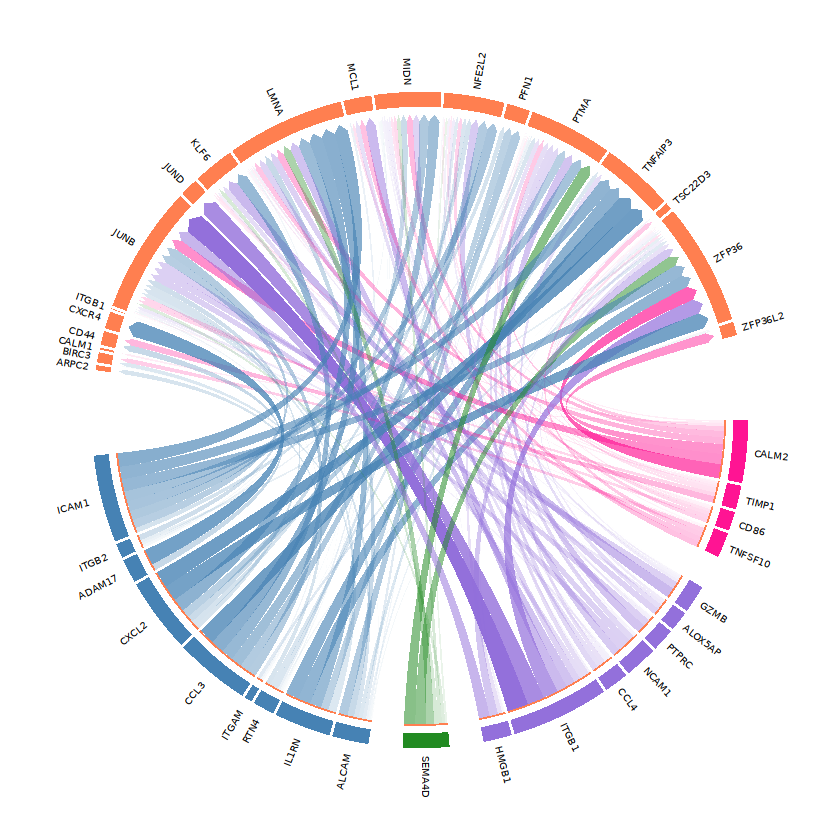

In [109]:
# Fix the link.visible issue
library(circlize)
circos.clear()

# Create the plot but override the problematic link.visible parameter
plot_fixed <- make_circos_plot(
  vis_circos_obj,
  transparency = TRUE,
  args.circos.text = list(cex = 0.5),
  link.visible = rep(TRUE, nrow(vis_circos_obj$links_circle))  # Fix the empty logical vector
)

In [110]:
ligand_colors = ligand_colors_colorblind

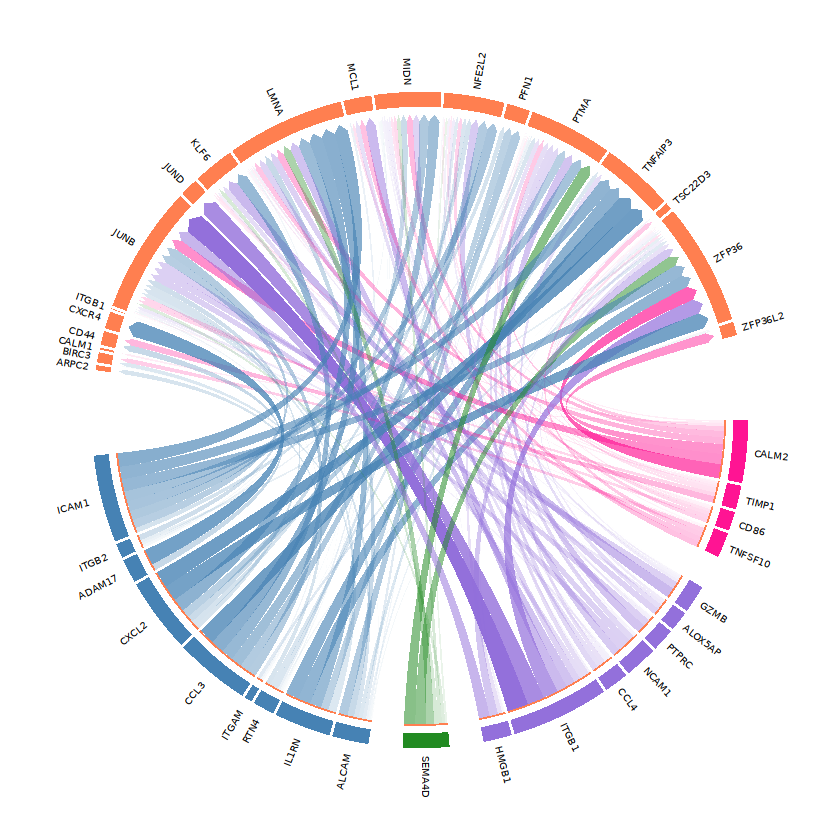

In [111]:
# Get only the cell types that are actually in your circos plot
actual_ligand_types <- unique(circos_links_filtered$ligand_type)
actual_target_types <- unique(circos_links_filtered$target_type)

# Filter ligand colors to only include those actually present
ligand_colors_filtered <- ligand_colors_colorblind[names(ligand_colors_colorblind) %in% actual_ligand_types]

# Create legend with only the colors that appear in your plot
legend_colors <- c(ligand_colors_filtered, target_colors)
legend_labels <- c(names(ligand_colors_filtered), names(target_colors))

# Now create your legend
circos_legend <- ComplexHeatmap::Legend(
  labels = legend_labels,
  background = legend_colors,
  type = "point",
  grid_height = unit(3, "mm"),
  grid_width = unit(3, "mm"),
  labels_gp = grid::gpar(fontsize = 8)
)
# Capture the legend as a grob
circos_legend_grob <- grid::grid.grabExpr(ComplexHeatmap::draw(circos_legend))

# Make the circos plot
make_circos_plot(vis_circos_obj,
  transparency = TRUE,
  args.circos.text = list(cex = 0.5),
  link.visible = rep(TRUE, nrow(vis_circos_obj$links_circle))  # Fix the empty logical vector
)
p_circos_no_legend <- recordPlot()


In [112]:
mofa_factor3_ligands_interaction_with_legend = cowplot::plot_grid(p_circos_no_legend, circos_legend_grob, rel_widths = c(10, 6))

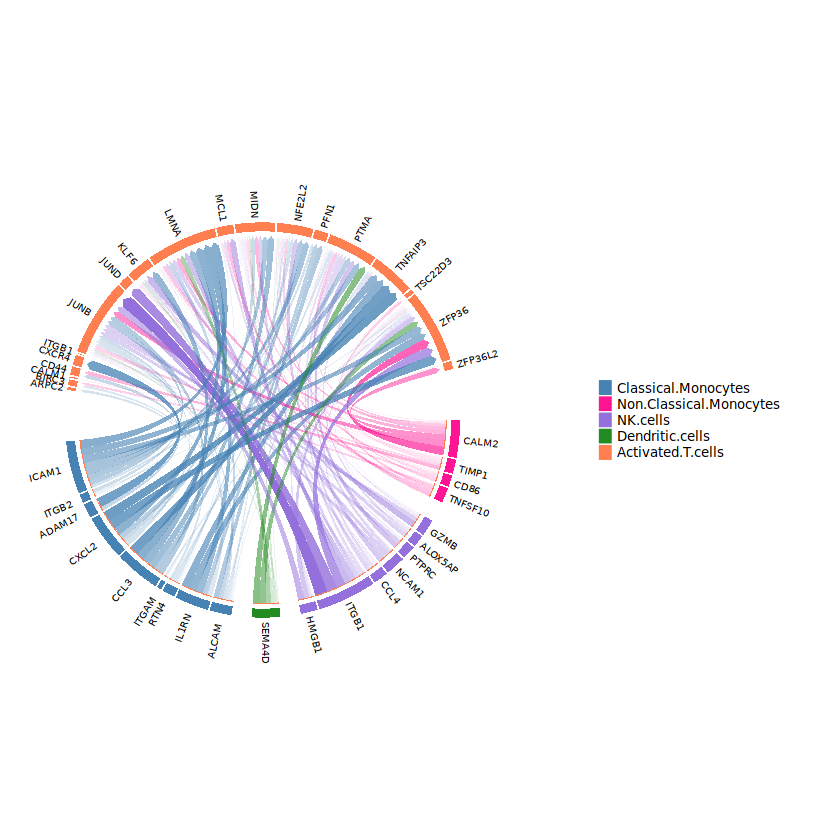

In [113]:
mofa_factor3_ligands_interaction_with_legend

In [74]:
setwd("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/cell_cell_interaction_networks/Classical.Monocytes/positive/new_colours")

In [75]:
save_plot_multiple2(mofa_factor3_ligands_interaction_with_legend, paste0("mofa_factor3_ligands_interaction_with_legend_positive_correlations_changed_colours"))
